In [1]:
import json
import os

import pandas as pd

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType
from backtester.indicators import Indicators
from backtester.market import Market, MarketDataFromCSV
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import MaCrossoverStrategy, StrategyDirection

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit


In [2]:

# Instantiate markets class
market = Market()

# add markets used for trading. Different Symbols but the same resolution (interval, unit_of_time)
# ALL INTERVALS SHOULD BE THE SAME!!
INTERVAL=1
UNIT_OF_TIME='hour'

DATE_FROM = "2017-01-01"
DATE_TO = "2025-01-01"

SYMBOL = "ETH/USD"

FAST_MA = 90
SLOW_MA = 150

ohlc = MarketDataFromCSV(symbol=SYMBOL,
                        date_from=DATE_FROM,
                        date_to=DATE_TO,
                        interval=INTERVAL,
                        unit_of_time=UNIT_OF_TIME,
                        path=f"{cwd}/datasets/binance/BINANCE_ETHUSDT_1H.csv").get_df()

market.add_market(
    symbol=SYMBOL,
    df=ohlc
    )

INDICATOR = Indicators.sma
INDICATOR_NAME = 'sma'

market.add_indicator(
    symbol=SYMBOL,
    interval=INTERVAL,
    unit_of_time=UNIT_OF_TIME,
    indicator_name=f"{INDICATOR_NAME}_{FAST_MA}",
    df=INDICATOR(ohlc, FAST_MA)
)
market.add_indicator(
    symbol=SYMBOL,
    interval=INTERVAL,
    unit_of_time=UNIT_OF_TIME,
    indicator_name=f"{INDICATOR_NAME}_{SLOW_MA}",
    df=INDICATOR(ohlc, SLOW_MA)
)

market.compile()

market.data


/Users/nick/Documents/www/alphakit/apps/backtester/src/backtester/market.py:35: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["time"] = df["time"].view("int64") // 10**9


{Timestamp('2017-08-17 04:59:59.999000'): {'num': 0,
  'time_open': Timestamp('2017-08-17 04:00:00'),
  'time_close': Timestamp('2017-08-17 04:59:59.999000'),
  'ETH/USD': {'open': 301.13,
   'high': 302.57,
   'low': 298.0,
   'close': 301.61,
   'volume': 125.66877,
   'indicators': {'sma_90': nan, 'sma_150': nan}}},
 Timestamp('2017-08-17 05:59:59.999000'): {'num': 1,
  'time_open': Timestamp('2017-08-17 05:00:00'),
  'time_close': Timestamp('2017-08-17 05:59:59.999000'),
  'ETH/USD': {'open': 301.61,
   'high': 303.28,
   'low': 300.0,
   'close': 303.1,
   'volume': 377.67246,
   'indicators': {'sma_90': nan, 'sma_150': nan}}},
 Timestamp('2017-08-17 06:59:59.999000'): {'num': 2,
  'time_open': Timestamp('2017-08-17 06:00:00'),
  'time_close': Timestamp('2017-08-17 06:59:59.999000'),
  'ETH/USD': {'open': 302.4,
   'high': 304.44,
   'low': 301.9,
   'close': 302.68,
   'volume': 303.86672,
   'indicators': {'sma_90': nan, 'sma_150': nan}}},
 Timestamp('2017-08-17 07:59:59.999000'

In [3]:

# create a portfolio of strategies
portfolio = Portfolio(weighted_strategies=[
    WeightedStrategy(
        weight=1,
        strategy=MaCrossoverStrategy(
            key="SMA_62_446",
            market=market,
            symbol=SYMBOL,
            direction=StrategyDirection.long,
            fast_indicator_key=f"{INDICATOR_NAME}_{FAST_MA}",
            slow_indicator_key=f"{INDICATOR_NAME}_{SLOW_MA}",
            sl_percent=0.3,
            tp_percent=0.6,
            sl_enabled=True,
            tp_enabled=True,
        ),
    ),
], output_scale=1)

print("Portfolio is ready!")


Portfolio is ready!


In [4]:


# instantiate exchange
exchange = Exchange(
            market=market,
            slippage=0.002, # 0.2%
            maker_fee=0.001, # 0.1%
            taker_fee=0.00075, # 0.075%
            market_type=MarketType.future,
            max_leverage=10,
            margin_allocation_type=MarginAllocationType.cross,
        )



In [5]:
from backtester.performance import PerformanceAnalyzer

# instantiate reporter
reporter = PerformanceAnalyzer(market=market,
                    exchange=exchange,
                    portfolio=portfolio,
                    benchmark_symbols=[SYMBOL])


Candles Processed:  64651
Report {
  "ETH/USD": {
    "annualized_volatility_percent": 89.72824923026353,
    "cagr_percent": 38.49233712150284,
    "calmar_ratio": 0.4096432748944871,
    "gross_return_percent": 1105.2251655629107,
    "max_drawdown_percent": -93.9655,
    "net_return_percent": 1005.2251655629107,
    "recovery_factor": 10.697810515576888,
    "sharpe_ratio": 0.8190021481833264,
    "sortino_ratio": 1.192185980714378
  },
  "algo": {
    "annualized_volatility_percent": 59.315764744395786,
    "avg_holding_period_min": 8609.464285714286,
    "avg_win_loss_ratio": 2.640374406930025,
    "cagr_percent": 54.151688632476144,
    "calmar_ratio": 0.8178124408614731,
    "closed_trades": 224.0,
    "gross_return_percent": 2436.1156717390345,
    "loser_trades": 127.0,
    "max_consecutive_losses": 7.0,
    "max_drawdown_percent": -66.2153,
    "net_return_percent": 2336.1156717390345,
    "profit_factor": 2.016663917104035,
    "recovery_factor": 35.280607269813956,
    "sha

Matplotlib is building the font cache; this may take a moment.


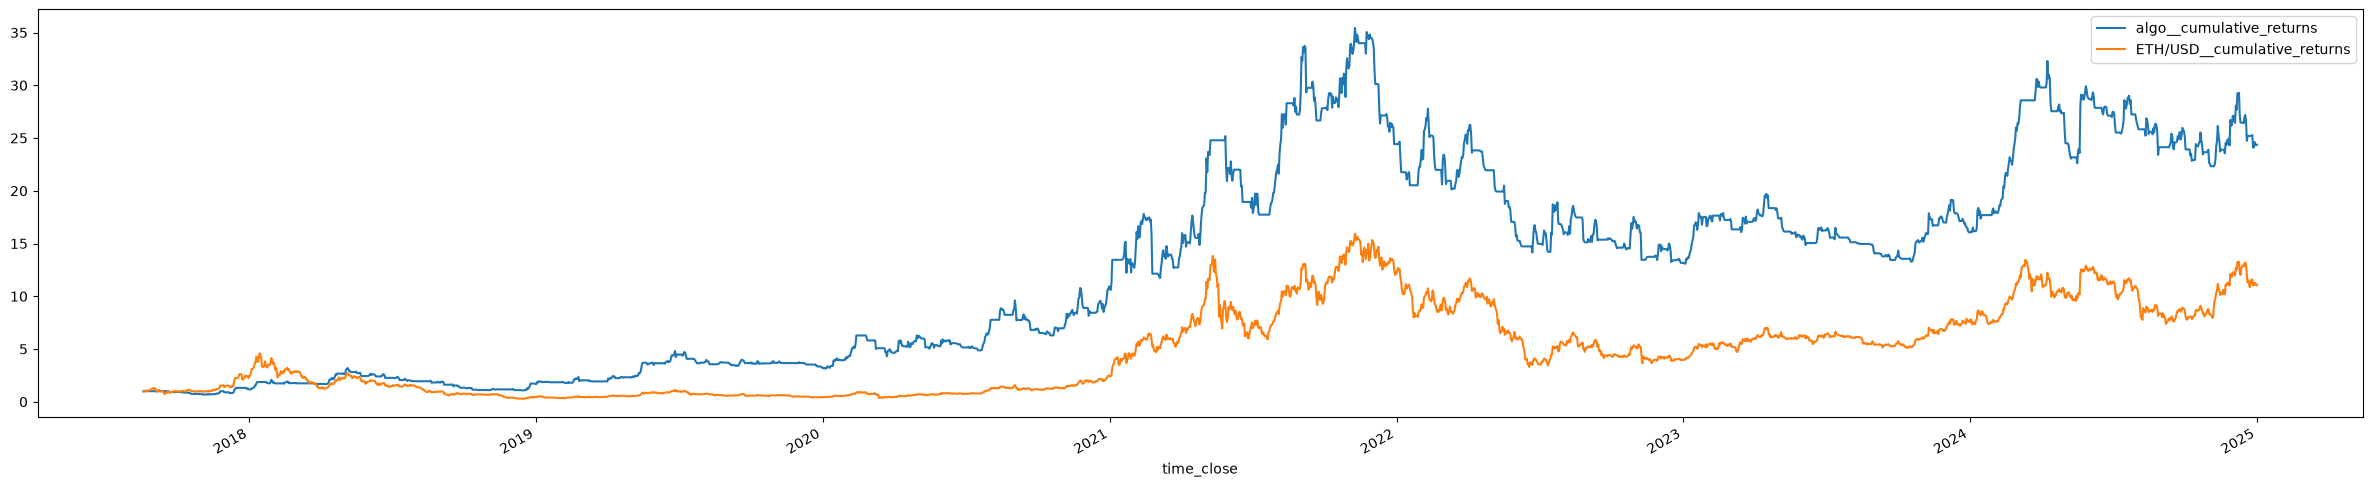

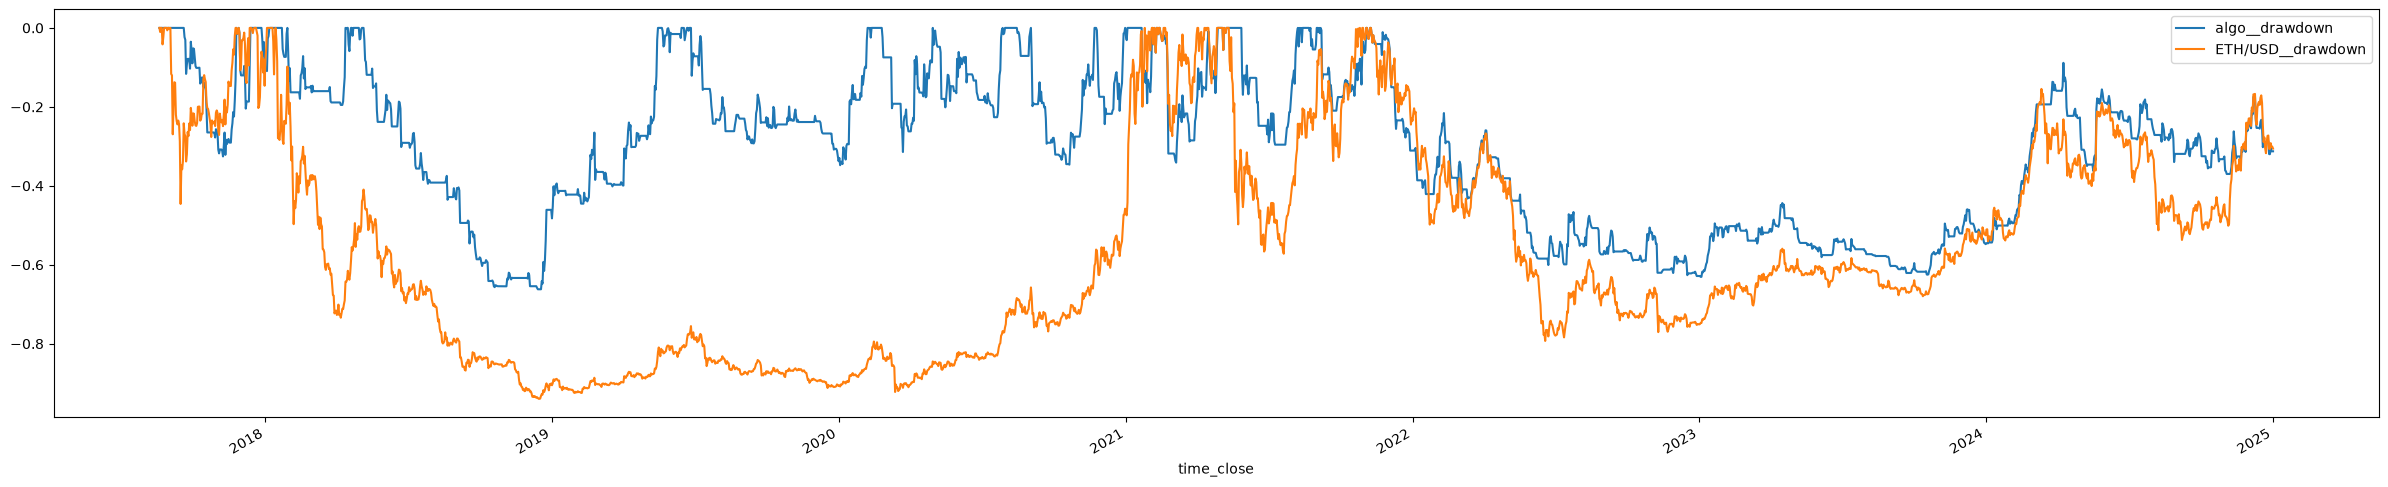

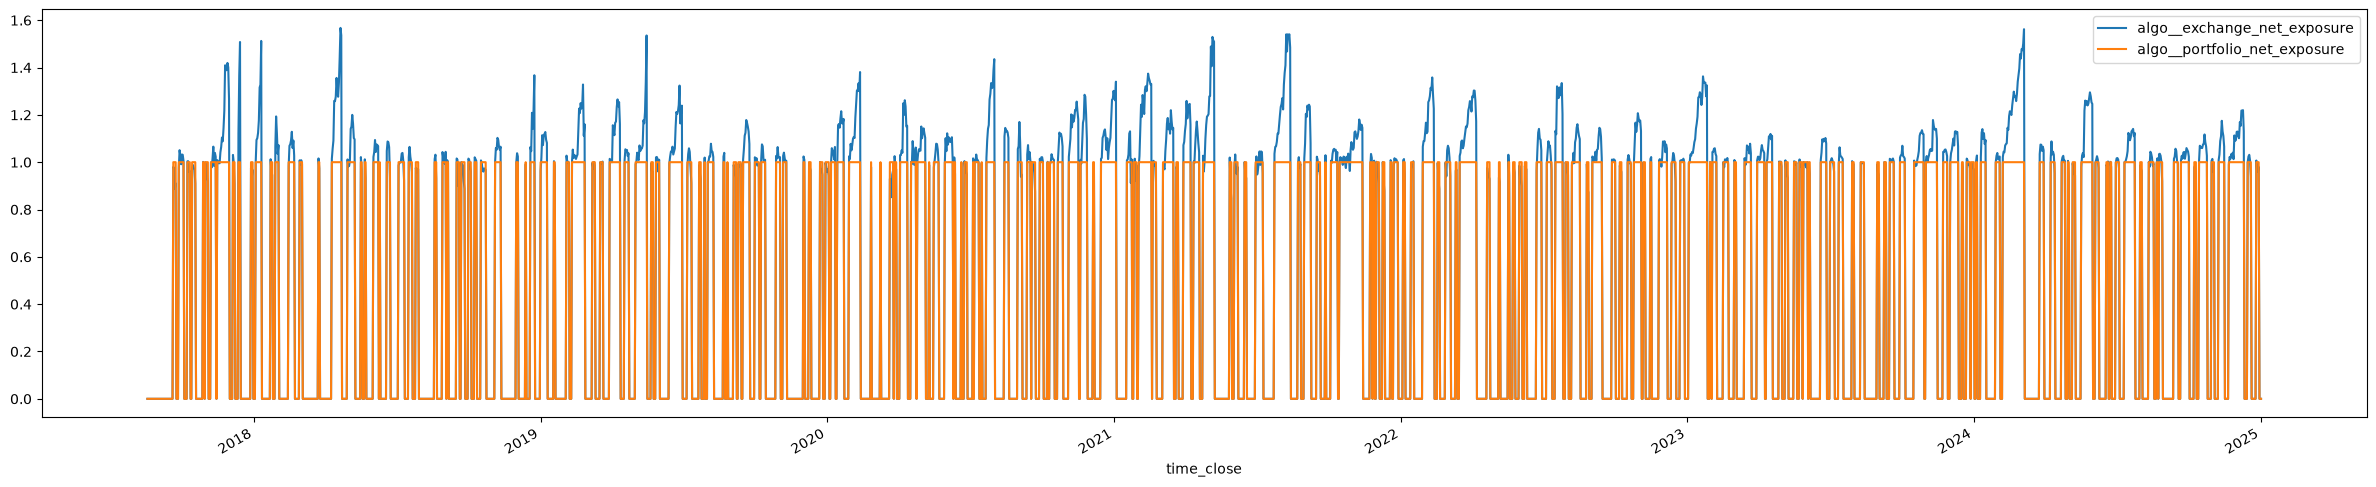

In [6]:
# run only one next step
market.reset()
# market.get_market_by_num(15246)
# market.merged.tail(93)

backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter)
# deposit some funds so we can trade
backtest.exchange.transactions.add_deposit(asset="USD", volume=1000)
backtest.run_all()

# Print Report
print("Candles Processed: ", backtest.market.current['num'])
print("Report", json.dumps(backtest.reporter.summary, sort_keys=True, indent=2, default=str))

if backtest.reporter.merged is not None:
    # Print a chart to compare the returns
    backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns"
        ], figsize=(30,6))

    backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown"
        ], figsize=(30,6))

    backtest.reporter.merged.plot(x="time_close", y=[
        "algo__exchange_net_exposure",
        "algo__portfolio_net_exposure"
        ], figsize=(30,6))

In [7]:
# market.merged
pd.DataFrame(backtest.exchange.get_logs())

,time,message
0,2017-08-17 05:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
1,2017-09-19 02:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
2,2017-09-23 08:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
3,2017-09-26 01:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
4,2017-10-03 22:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
...,...,...
444,2024-12-10 19:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
445,2024-12-14 12:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
446,2024-12-19 11:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
447,2024-12-25 22:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...


In [8]:
# get dataframe with all the trades that were executed
def _trade_to_dict(trade):
    d = trade.__dict__.copy()
    for k, v in d.items():
        if hasattr(v, "value"):
            d[k] = v.value
    return d

pd.DataFrame([_trade_to_dict(t) for t in backtest.reporter.trades])


,symbol,side,time_open,time_close,open_price,close_price,close_reason,pnl,result,holding_period
0,ETH/USD,long,1505789999999000000,1506157199999000000,289.97,268.74,signal,-0.073214,loser,367200000000000
1,ETH/USD,long,1506391199999000000,1507071599999000000,295.00,290.82,signal,-0.014169,loser,680400000000000
2,ETH/USD,long,1507089599999000000,1507093199999000000,293.41,293.50,signal,0.000307,winner,3600000000000
3,ETH/USD,long,1507391999999000000,1507755599999000000,310.06,303.29,signal,-0.021834,loser,363600000000000
4,ETH/USD,long,1507917599999000000,1508338799999000000,346.46,293.13,signal,-0.153928,loser,421200000000000
...,...,...,...,...,...,...,...,...,...,...
219,ETH/USD,long,1730948399999000000,1731704399999000000,2871.80,3090.60,signal,0.076189,winner,756000000000000
220,ETH/USD,long,1732064399999000000,1732190399999000000,3107.06,3147.75,signal,0.013096,winner,126000000000000
221,ETH/USD,long,1732193999999000000,1733860799999000000,3284.99,3628.82,signal,0.104667,winner,1666800000000000
222,ETH/USD,long,1734181199999000000,1734609599999000000,3868.84,3705.62,signal,-0.042188,loser,428400000000000
